In [1]:
import pickle
import numpy as np
import os
import sys
import plotly.graph_objs as go

path = os.getcwd().split(os.sep +'GUI')[0]
if path not in sys.path:
    sys.path.append(path)

import neurolib.dashboard.layout as layout
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data


In [2]:
# plot and save for all data points
from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import os

path = os.path.join(os.getcwd(), "plots_")

aln = ALNModel()
data.set_parameters(aln)

state_vars = aln.state_vars

In [3]:
##### LOAD BOUNDARIES
with open('boundary_bi.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_bi_exc = load_array[0]
boundary_bi_inh = load_array[1]

with open('boundary_LC.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_exc = load_array[0]
boundary_LC_inh = load_array[1]

with open('boundary_LCbi.pickle','rb') as file:
    load_array= pickle.load(file)
boundary_LC_up_exc = load_array[0]
boundary_LC_up_inh = load_array[1]

In [4]:
def setcase(obj, active):
    set_case(case)

def set_case(old_case):
    b0 = button0.active
    b1 = button1.active
    b2 = button2.active
    b3 = button3.active
    b4 = button4.active
    #b5 = button5.active
    case_ = str(b0) + str(b1) + '0' + str(b3) + str(b4) #+ str(b5)
    if b2 == 1:
        case_ = case_ + 'max'
    
    
    functions.setdefaultmarkersize(layout.markersize, scatter1)
    functions.setdefaultmarkersize(layout.markersize, scatter2)
    functions.setdefaultmarkersize(layout.markersize, scatter3)
    functions.setdefaultmarkersize(layout.markersize, scatter4)
    
    global exc_, inh_, no_c_, both_c_
    global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
    global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4
    global img_path
    
    
    #print("switch case to ", case_)
    fig.layout.annotations = fig.layout.annotations[:9]
    fig.layout.images = []
    
    global case
    case = case_
    
    readpath = '.' + os.sep + 'data' + os.sep + str(case_[:5]) + os.sep
    data_array = data.read_data(readpath, case_)
    exc_, inh_, both_c_, no_c_ = data_array[0:4]
    exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
    exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]
    data.update_data(fig, exc_1, inh_1, exc_2, inh_2, exc_3, inh_3, exc_4, inh_4)
        
    img_path = set_image_path(case_)
        
    return [case_, img_path, exc_, inh_, no_c_, both_c_,
                exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2,
                exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4]
        
def set_image_path(str_case):
    img_path_ = 'plots_' + os.sep + str_case[:5] + os.sep
    return img_path_
    
def show_trace(trace, points, state):
    ind = points.point_inds
    
    if len(ind) == 0:
        return
        
    functions.setdefaultmarkersize(0, trace)
    functions.setmarkersize(ind[-1], layout.background_markersize, trace)
    functions.setdefaultmarkersize(layout.markersize, scatter1)
    functions.setdefaultmarkersize(layout.markersize, scatter2)
    functions.setdefaultmarkersize(layout.markersize, scatter3)
    functions.setdefaultmarkersize(layout.markersize, scatter4)

    data.plot_trace(aln, data_background.x[ind[-1]], data_background.y[ind[-1]], fig.data[7], fig.data[8])
    
def show_arrow_and_traces(trace, points, state):
    ind = points.point_inds
    
    if len(ind) == 0:
        return
        
    functions.setdefaultmarkersize(0, scatter_background)
    for tr in fig.data[1:5]:
        functions.setdefaultmarkersize(layout.markersize, tr)
    functions.setmarkersize(ind[-1], 2. * layout.markersize, trace)
    
    fig.layout.annotations = fig.layout.annotations[:9]
    
    if trace.uid == '1':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost1[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_1[ind[-1]], inh_1[ind[-1]], lenx_1[ind[-1]], leny_1[ind[-1]]
    elif trace.uid == '2':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost2[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_2[ind[-1]], inh_2[ind[-1]], lenx_2[ind[-1]], leny_2[ind[-1]]
    elif trace.uid == '3':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost3[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_3[ind[-1]], inh_3[ind[-1]], lenx_3[ind[-1]], leny_3[ind[-1]]
    elif trace.uid == '4':
        fig.layout.annotations[8].text = layout.change_cost_layout(cost4[ind[-1]], case)
        e_, i_, lx_, ly_ = exc_4[ind[-1]], inh_4[ind[-1]], lenx_4[ind[-1]], leny_4[ind[-1]]                                                                                
    
    data.plot_trace(aln, e_, i_, fig.data[7], fig.data[8])
    
    if trace.uid in ['1', '3']:
        xarrow, reshapex = functions.get_x_arrow(e_,i_,lx_)
        fig.add_annotation(xarrow)

        if reshapex != 1.:
            rescale_ann = functions.get_x_rescale_annotation(reshapex,e_,i_,lx_)
            fig.add_annotation(rescale_ann)
    
    if trace.uid in ['2', '3']:
        yarrow, reshapey = functions.get_y_arrow(e_,i_,ly_)
        fig.add_annotation(yarrow)

        if reshapey != 1.:
            rescale_ann = functions.get_y_rescale_annotation(reshapey,e_,i_,ly_)
            fig.add_annotation(rescale_ann)
            
    folder = int(trace.uid)
    if case[-3:] == 'max':
        folder = str(folder) + 'max'
    
    img = layout.get_img(img_path, folder, ind[-1])
    fig.layout.images = []
    fig.add_layout_image(img)

In [6]:
global img_path
global case
global exc_, inh_, no_c_, both_c_
global exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2
global exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4

cmap = layout.getcolormap()
darkgrey, midgrey, lightgrey, color_bi_updown, color_LC, color_bi_uposc = layout.getcolors()

img_path = 'plots_' + os.sep + '00000' + os.sep
case = '00000'
readpath = '.' + os.sep + 'data' + os.sep + str(case) + os.sep

with open(readpath + os.sep + 'bi.pickle','rb') as file:
    load_array= pickle.load(file)
ext_exc = load_array[0]
ext_inh = load_array[1]

data_array = data.read_data(readpath, case)
exc_, inh_, both_c_, no_c_ = data_array[0:4]
exc_1, inh_1, lenx_1, leny_1, exc_2, inh_2, lenx_2, leny_2 = data_array[4:12]
exc_3, inh_3, lenx_3, leny_3, exc_4, inh_4, lenx_4, leny_4, cost1, cost2, cost3, cost4 = data_array[12:]

data1, data2, data3, data4 = data.get_scatter_data(exc_1, inh_1, exc_2, inh_2, exc_3, inh_3, exc_4, inh_4)

data_background = data.get_data_background(exc_1, inh_1, exc_2, inh_2, exc_3, inh_3, exc_4, inh_4)

trace00, trace01 = data.get_step_current_traces(aln)
trace10, trace11 = layout.get_empty_traces()

bistable_regime = layout.get_bistable_paths(boundary_bi_exc, boundary_bi_inh)
oscillatory_regime = layout.get_osc_path(boundary_LC_exc, boundary_LC_inh)
LC_up_regime = layout.get_LC_up_path(boundary_LC_up_exc, boundary_LC_up_inh)


fig = go.FigureWidget([data_background, data1, data2, data3, data4, trace00, trace01, trace10, trace11])
fig.update_layout(layout.get_layout())
fig.update_layout(updatemenus=layout.get_updatemenus())
fig.update_layout(shapes=[bistable_regime, oscillatory_regime, LC_up_regime])

fig.add_annotation(layout.get_label_bistable())
fig.add_annotation(layout.get_label_osc())
fig.add_annotation(layout.get_label_osc_up())
fig.add_annotation(layout.get_label_down())
fig.add_annotation(layout.get_label_up())
fig.add_annotation(layout.get_info_text())
fig.add_annotation(layout.get_label_exc())
fig.add_annotation(layout.get_label_inh())
fig.add_annotation(layout.get_label_cost())

fig.update_annotations()

scatter_background = fig.data[0]
scatter1 = fig.data[1]
scatter2 = fig.data[2]
scatter3 = fig.data[3]
scatter4 = fig.data[4]

scatter1.uid = '1'
scatter2.uid = '2'
scatter3.uid = '3'
scatter4.uid = '4'

button0 = fig.layout.updatemenus[0]
button1 = fig.layout.updatemenus[1]
button2 = fig.layout.updatemenus[2]
button3 = fig.layout.updatemenus[3]
button4 = fig.layout.updatemenus[4]
#button5 = fig.layout.updatemenus[5]


scatter1.on_click(show_arrow_and_traces)
scatter2.on_click(show_arrow_and_traces)
scatter3.on_click(show_arrow_and_traces)
scatter4.on_click(show_arrow_and_traces)
scatter_background.on_click(show_trace)

button0.on_change(setcase, 'active')
button1.on_change(setcase, 'active')
button2.on_change(setcase, 'active')
button3.on_change(setcase, 'active')
button4.on_change(setcase, 'active')
#button5.on_change(setcase, 'active')

display(fig)

FigureWidget({
    'data': [{'hoverinfo': 'x+y',
              'marker': {'color': 'rgb(100,100,100)',
       …

0.47500000000000014 0.4750000000000002
5.0
5.0 0.0 0.0 17068.886839794603
5.0 0.0 10.0 17069.766662953607
5.0 0.0 20.0 17070.00282567595
5.0 0.0 30.0 17070.037994577247
5.0 0.0 40.0 17069.745497226286
5.0 0.0 50.0 17068.72541578589
5.0 0.0 60.0 17065.3769121319
5.0 0.0 70.0 17047.140705117832
5.0 10.0 0.0 17068.886839794603
5.0 10.0 10.0 17069.698181013373
5.0 10.0 20.0 17069.8267476279
5.0 10.0 30.0 17069.62374366648
5.0 10.0 40.0 17068.728674508722
5.0 10.0 50.0 17065.81502511902
5.0 10.0 60.0 17051.347837855683
5.0 20.0 0.0 17068.886839794603
5.0 20.0 10.0 17069.588553907495
5.0 20.0 20.0 17069.521089893267
5.0 20.0 30.0 17068.777927372677
5.0 20.0 40.0 17066.26005343377
5.0 20.0 50.0 17054.64880947688
5.0 30.0 0.0 17068.886839794603
5.0 30.0 10.0 17069.410706163864
5.0 30.0 20.0 17068.90451130773
5.0 30.0 30.0 17066.816963233254
5.0 30.0 40.0 17057.65706842396
5.0 40.0 0.0 17068.886839794603
5.0 40.0 10.0 17069.098640417316
5.0 40.0 20.0 17067.55557798309
5.0 40.0 30.0 17060.725081

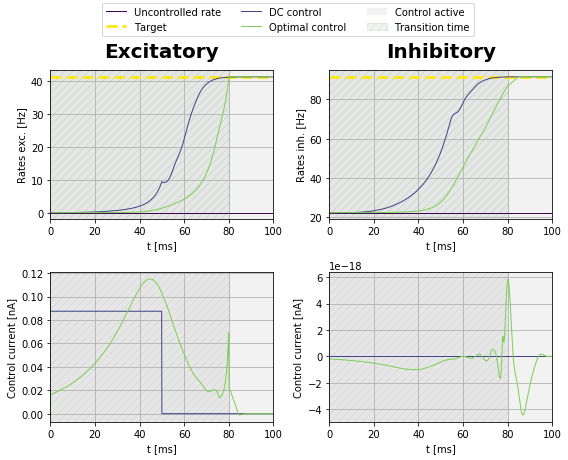

In [9]:
ind = [21]
control_data = data.read_control(readpath, case)

grid_resolution = layout.grid_resolution

amp_range = np.arange(5, 10, 1.)
start_range = np.arange(0., 70, 10)
#dur_range = np.arange(0, 50, 10)

weights = [1., 0., 1.]

trans_time = 0.8

for i in ind:
    
    print(ext_exc[i], ext_inh[i])
    
    mincost = 1000.
    minind = [0,0,0]
    dist_ = data.dist_right(ext_exc[i], ext_inh[i], ext_exc, ext_inh, grid_resolution)
    
    opt_cntrl = control_data[2][i][:,:,100:-100]
    opt_cost_node = control_data[4][i]

    for a in amp_range:
        print(a)
        for start in start_range:
            for dur in np.arange(0, 80 - start, 10):
                cost_DC = data.DC_trace(aln, ext_exc[i], ext_inh[i], start, dur,
                                        [a * dist_,0], case, trans_time, weights,
                  opt_cntrl, opt_cost_node, weights)
                total_cost = weights[0] * cost_DC[0][0][0] + weights[1] * sum(cost_DC[1][0][:]) + weights[2] * sum(cost_DC[2][0][:])
                print(a, start, dur, total_cost)
                if total_cost < mincost:
                    minind = [a, start, dur]
                    mincost = total_cost
                    #print("minimal index = ", a, start, dur)

    print('minimal cost = ', mincost, ' for indices = ', minind)

    print("EXAMPLE 1")
    data.DC_trace(aln, ext_exc[i], ext_inh[i], minind[1], minind[2], [minind[0] * dist_,0], case, trans_time, weights,
                  opt_cntrl, opt_cost_node, weights, plot_=True)